## 1. Imports

In [34]:
import pandas as pd
from IPython.display import display, Markdown

import importlib
import utils.describing_utils
importlib.reload(utils.describing_utils)

from utils.describing_utils import (
    get_project_root,
    ensure_dir,
    load_dataset,
    create_dataset_description_bundle,
    detect_dataset_anomalies,
    dataset_overview_tables,
)

## 2. Project config

In [35]:
PROJECT_ROOT = get_project_root()
DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = ensure_dir(PROJECT_ROOT / "outputs" / "describing")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/sraveendran/Documents/GitHub/ML-Assignment
Dataset directory: /Users/sraveendran/Documents/GitHub/ML-Assignment/dataset
Output directory: /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/describing


## 3. Load dataset

In [36]:
df_raw, dataset_path = load_dataset(DATASET_DIR)

print(f"Loaded dataset from: {dataset_path.name}")
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

Loaded dataset from: hotel_bookings.csv
Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4. Overview

In [37]:
display(Markdown(f"**Rows:** {df_raw.shape[0]} **Columns:** {df_raw.shape[1]}"))
display(df_raw.dtypes.to_frame("dtype"))
display(df_raw.info())

**Rows:** 119390 **Columns:** 32

,dtype
hotel,str
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,str
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

None

## 5. Summary

In [38]:
overview_tables = dataset_overview_tables(df_raw)

display(Markdown("### Column-level summary"))
display(overview_tables["dtype_summary"].head(20))

if not overview_tables["numeric_summary"].empty:
    display(Markdown("### Numerical summary"))
    display(overview_tables["numeric_summary"].head(20))

if not overview_tables["categorical_summary"].empty:
    display(Markdown("### Categorical summary"))
    display(overview_tables["categorical_summary"].head(20))

overview_tables["dtype_summary"].to_csv(OUTPUT_DIR / "dataset_description_dtype_summary_preview.csv", index=False)

### Column-level summary

,column,dtype,missing_count,missing_percent,unique_count
24,company,float64,112593,94.31,352
23,agent,float64,16340,13.69,333
13,country,str,488,0.41,177
27,adr,float64,0,0.00,8879
31,reservation_status_date,str,0,0.00,926
2,lead_time,int64,0,0.00,479
25,days_in_waiting_list,int64,0,0.00,128
18,previous_bookings_not_canceled,int64,0,0.00,73
5,arrival_date_week_number,int64,0,0.00,53
8,stays_in_week_nights,int64,0,0.00,35


### Numerical summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent,skew
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0,0,0.00,0.536678
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0,0,0.00,1.346550
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0,0,0.00,-0.232583
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0,0,0.00,-0.010014
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0,0,0.00,-0.002000
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0,0,0.00,1.380046
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0,0,0.00,2.862249
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0,0,0.00,18.317805
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0,4,0.00,4.112590
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0,0,0.00,24.646545


### Categorical summary

,column,missing_count,missing_percent,unique_count,top_value,top_frequency
3,country,488,0.41,177,PRT,48590
11,reservation_status_date,0,0.00,926,2015-10-21,1461
1,arrival_date_month,0,0.00,12,August,13877
7,assigned_room_type,0,0.00,12,A,74053
6,reserved_room_type,0,0.00,10,A,85994
4,market_segment,0,0.00,8,Online TA,56477
2,meal,0,0.00,5,BB,92310
5,distribution_channel,0,0.00,5,TA/TO,97870
9,customer_type,0,0.00,4,Transient,89613
8,deposit_type,0,0.00,3,No Deposit,104641


## 6. Duplicates and Missing Counts

In [39]:
anomalies = detect_dataset_anomalies(df_raw)
anomalies_df = pd.DataFrame(
    [{"issue": key, "details": str(value)} for key, value in anomalies.items()]
)
display(anomalies_df)
anomalies_df.to_csv(OUTPUT_DIR / "dataset_description_anomalies_preview.csv", index=False)

,issue,details
0,row_count,119390
1,column_count,32
2,duplicate_rows,31994
3,missing_values_total,129425
4,high_missing_columns,{'company': 94.31}
5,potential_impossible_rows,"{'zero_total_guests': 180, 'negative_adr': 1}"
6,negative_numeric_counts,"{'is_canceled': 0, 'lead_time': 0, 'arrival_da..."
7,high_cardinality_columns,"{'country': 177, 'reservation_status_date': 926}"
8,target_distribution,"{'0': 75166, '1': 44224}"


## 7. Plot the graphs

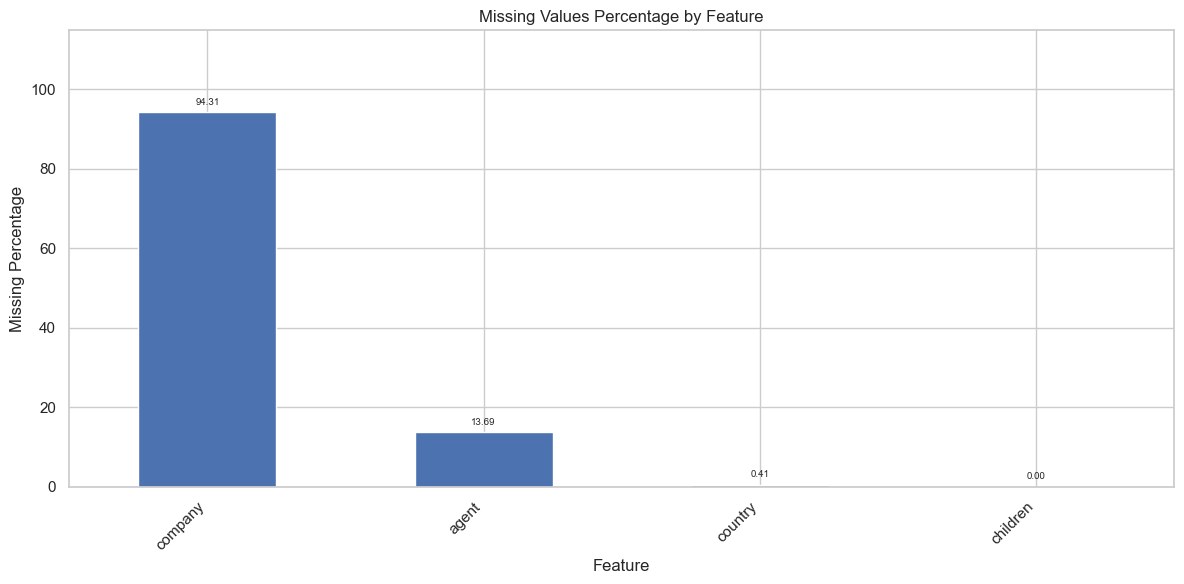

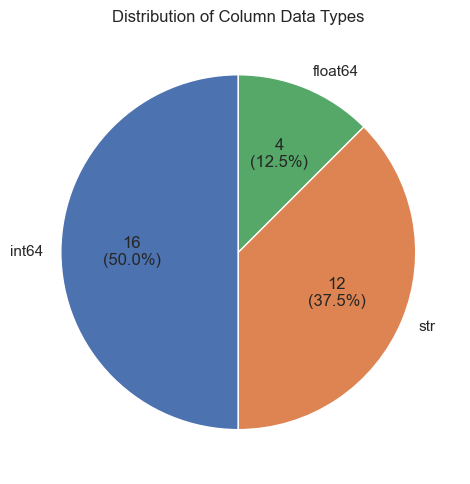

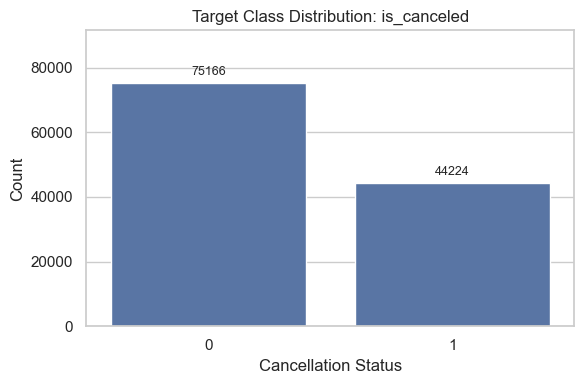

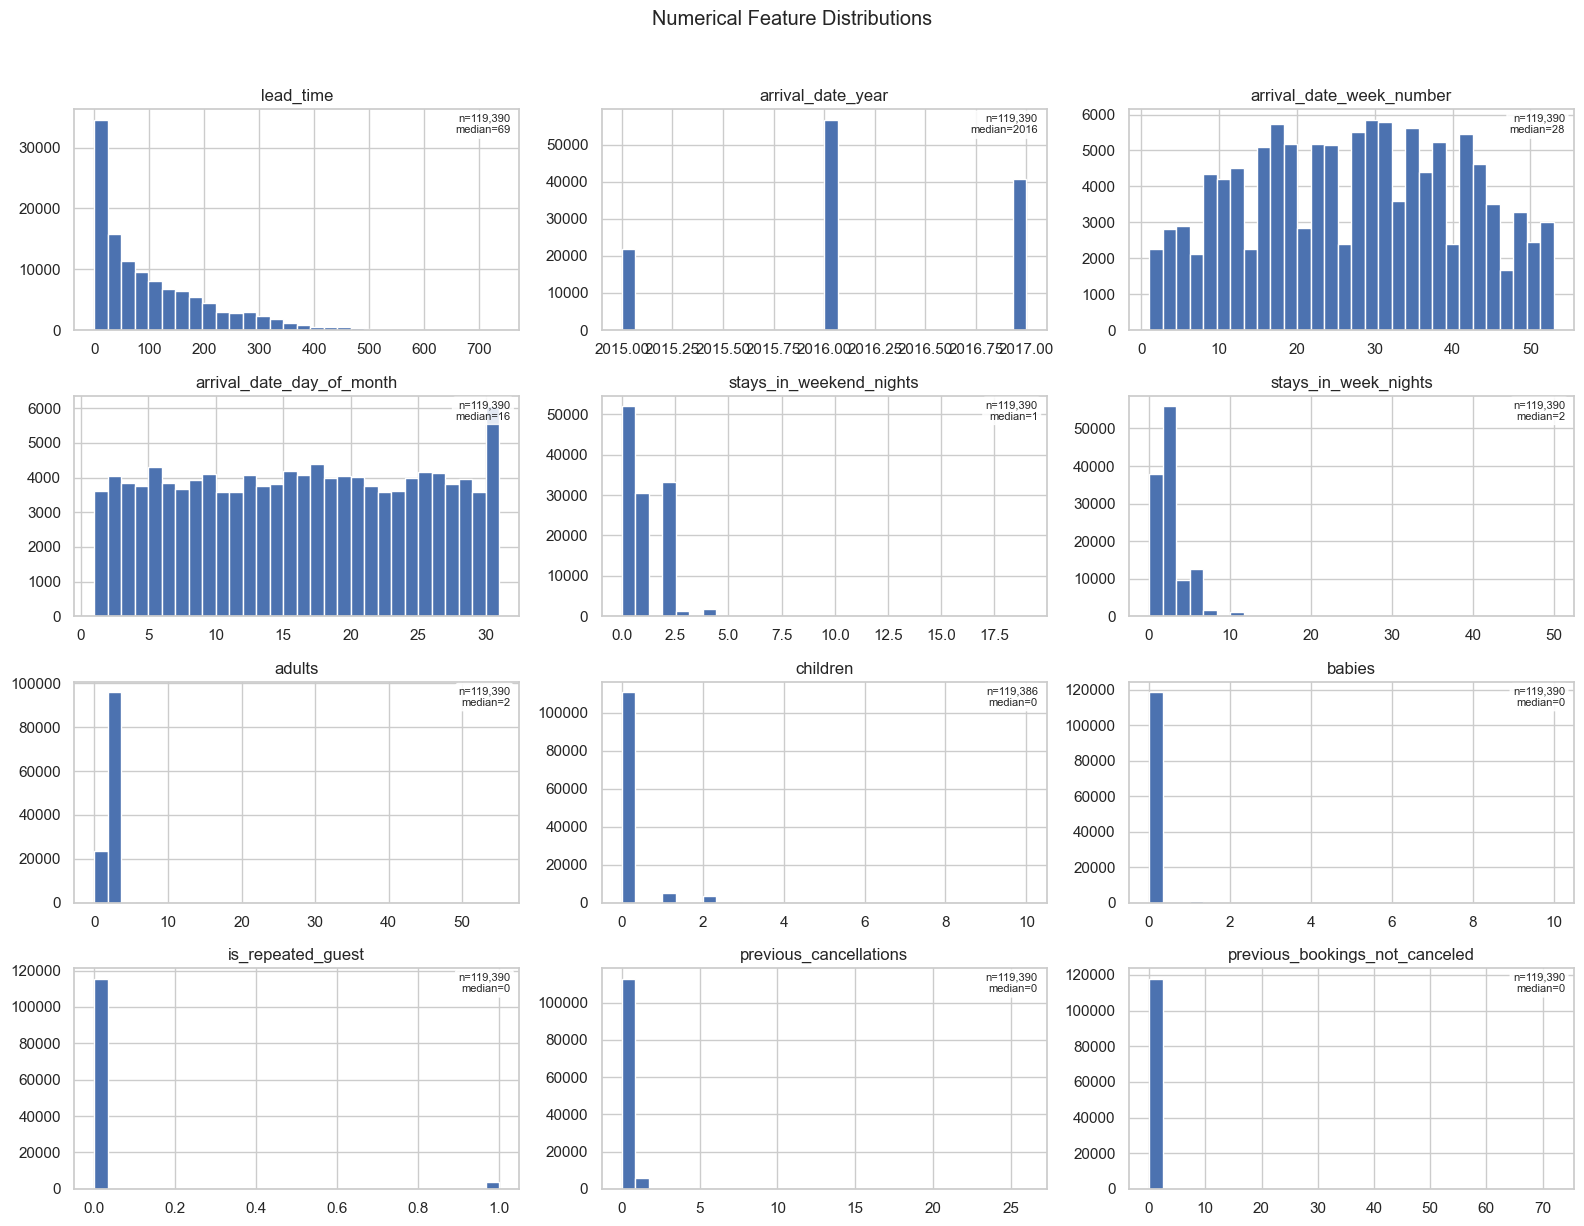

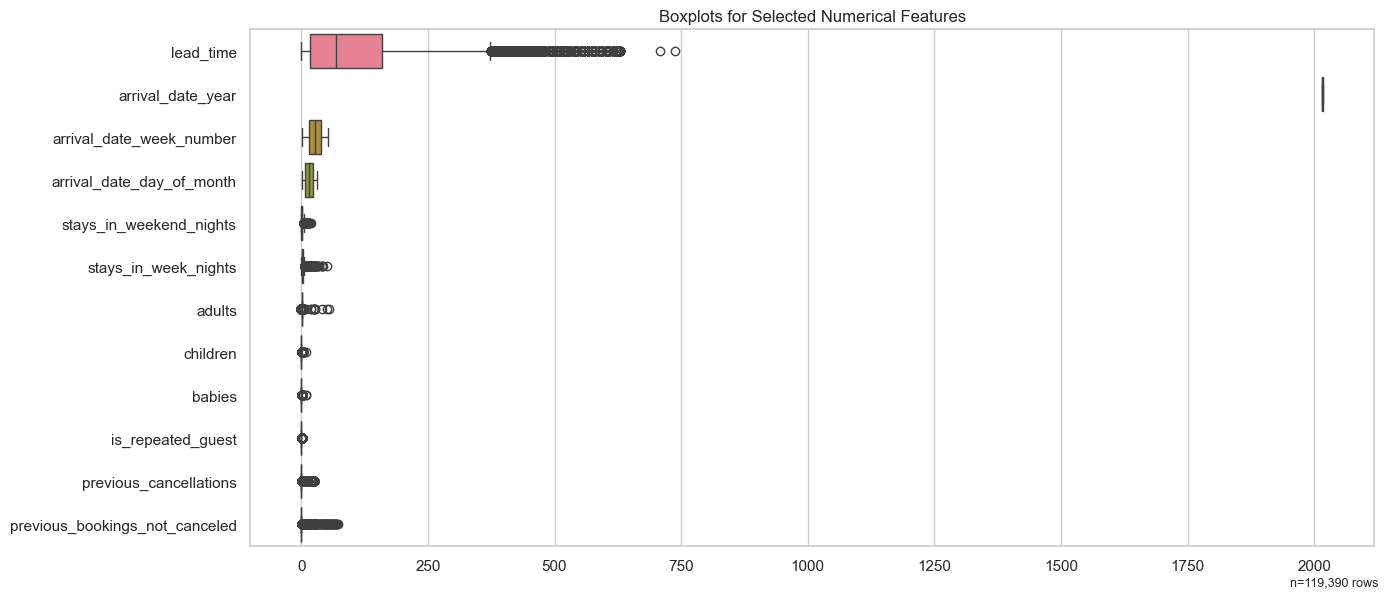

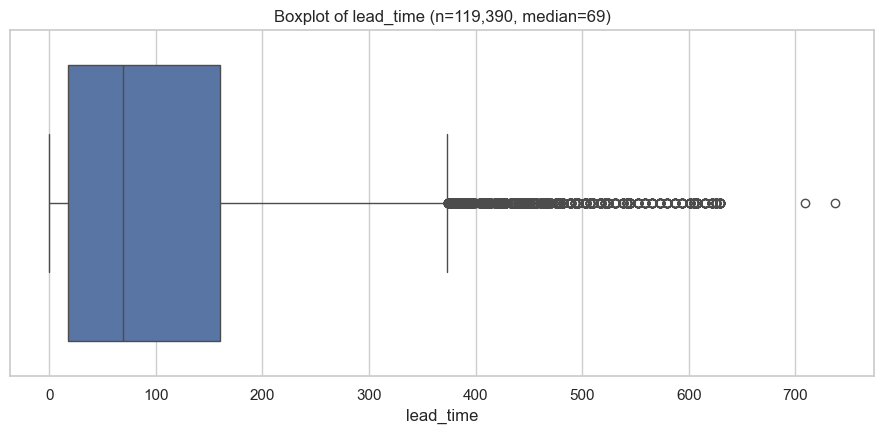

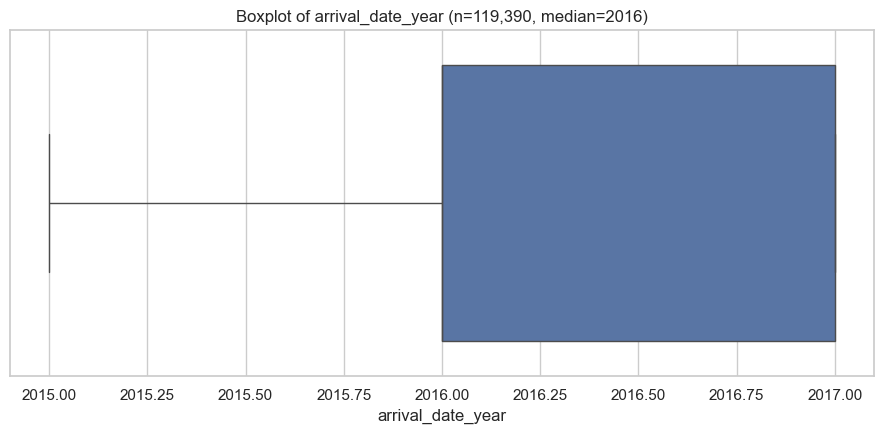

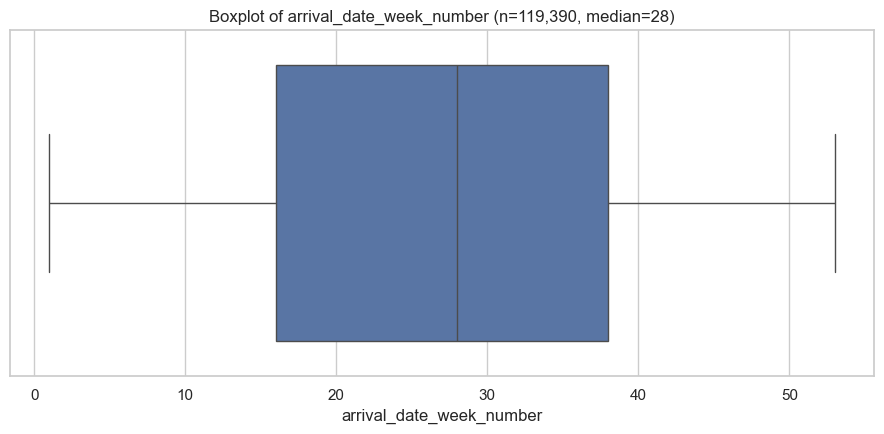

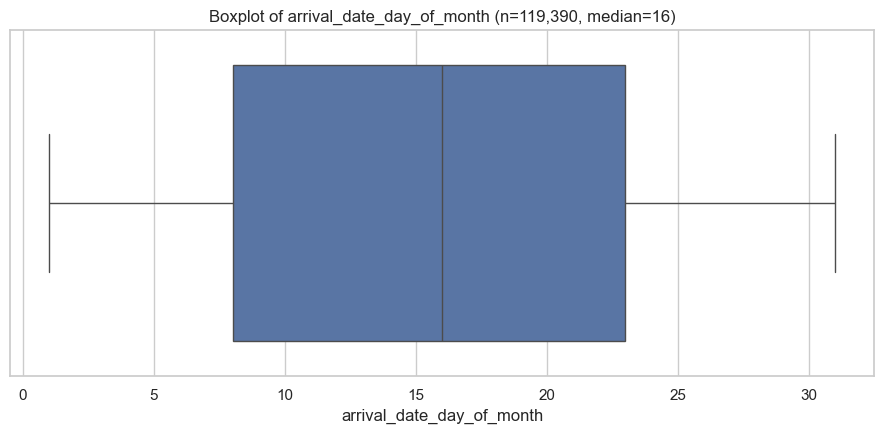

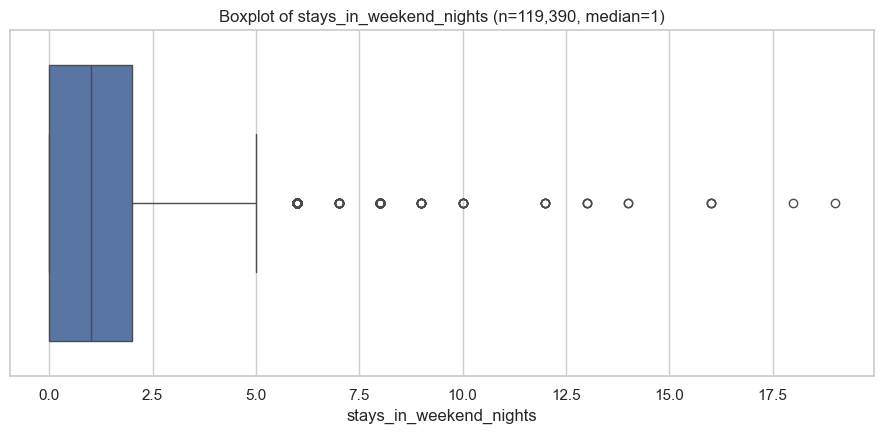

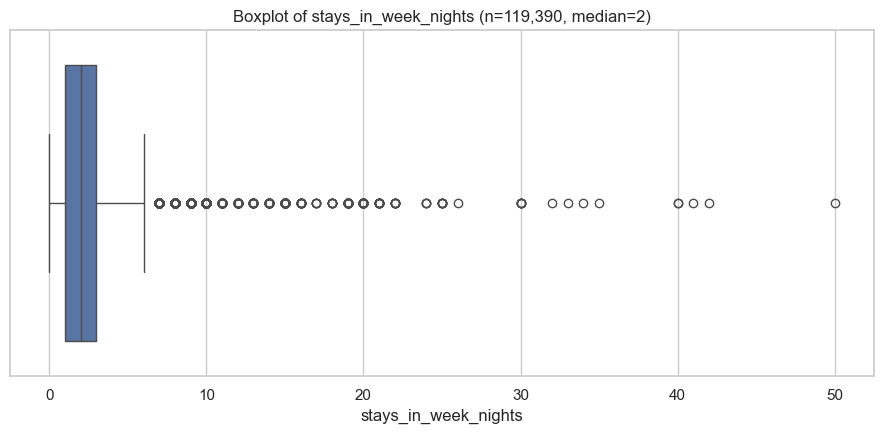

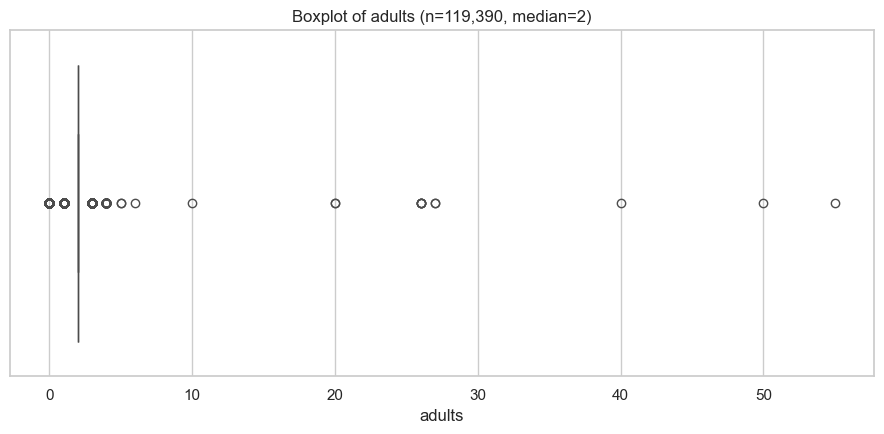

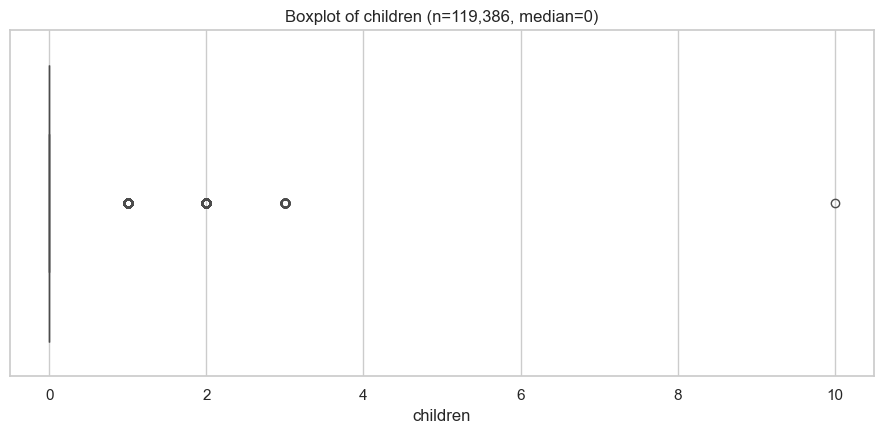

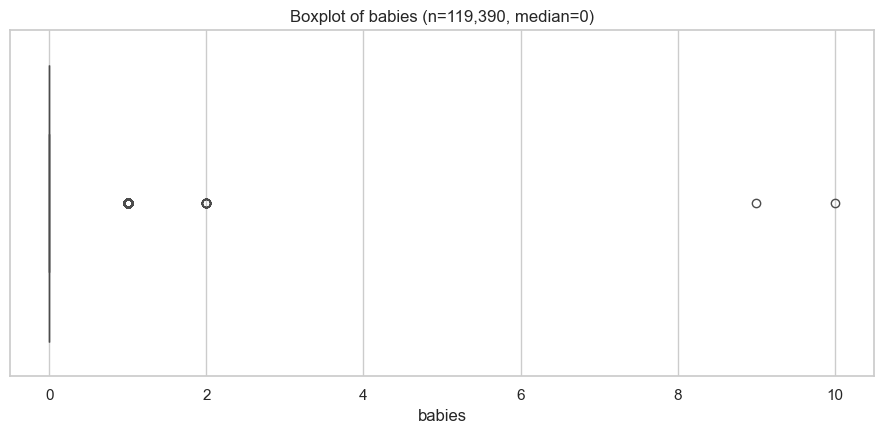

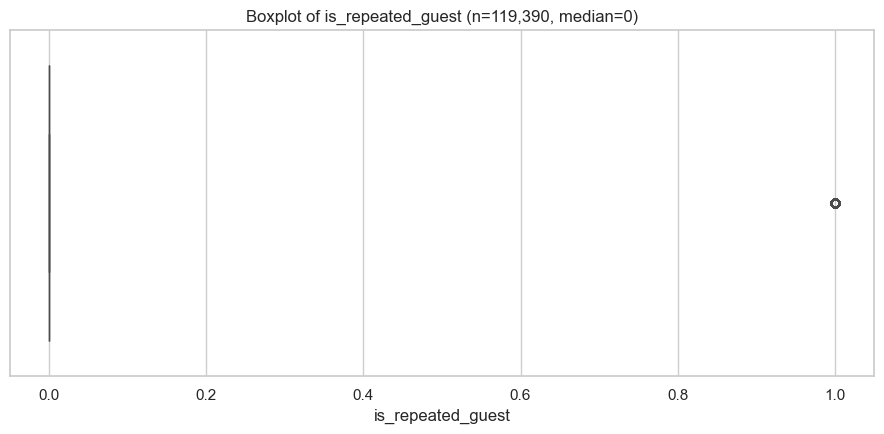

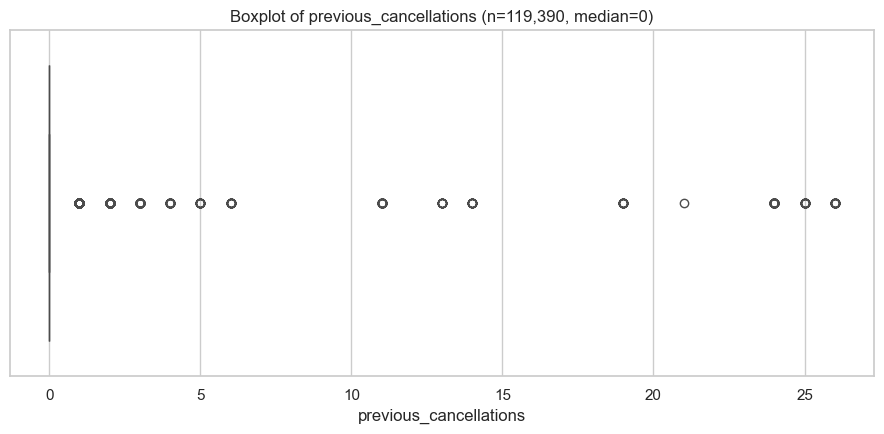

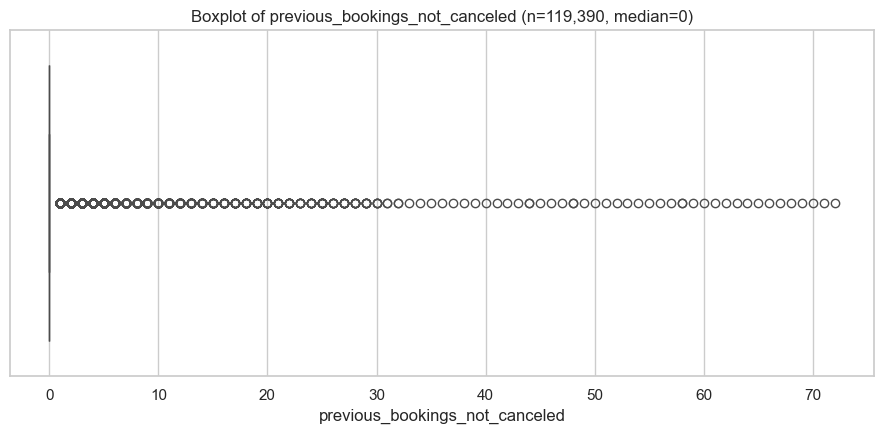

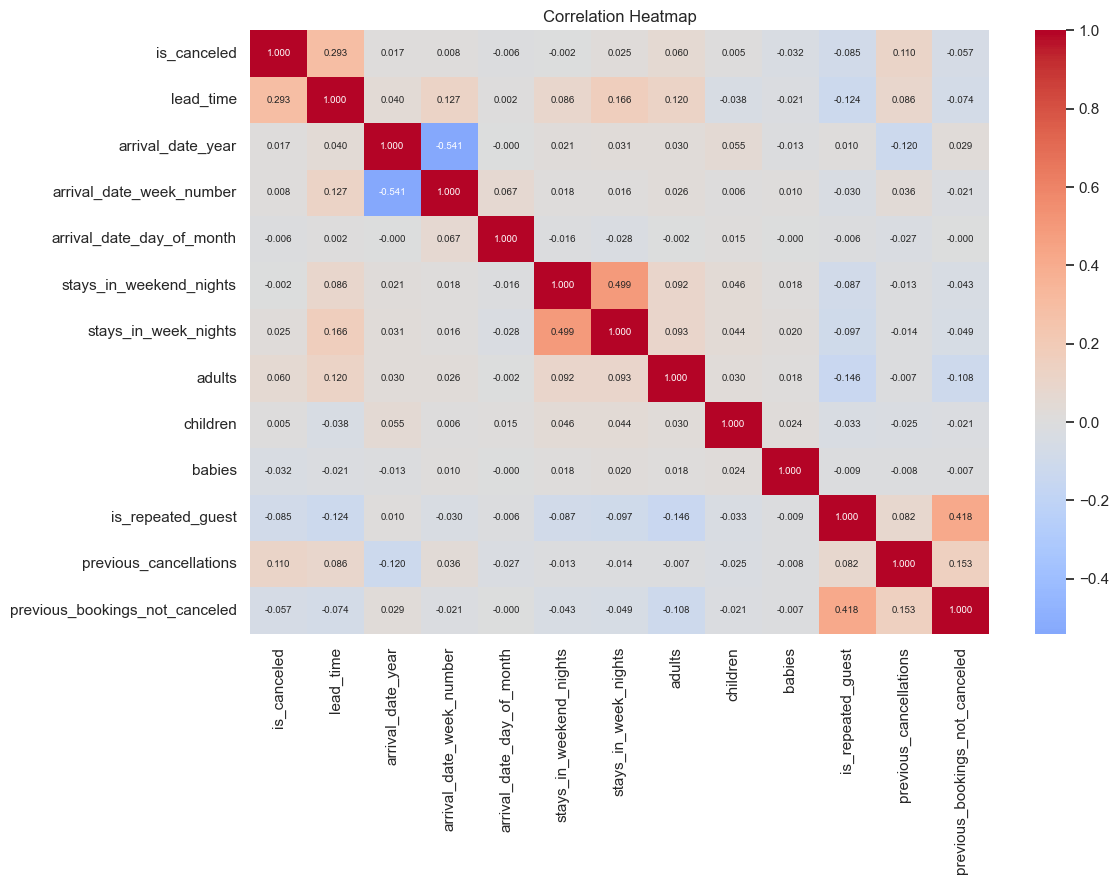

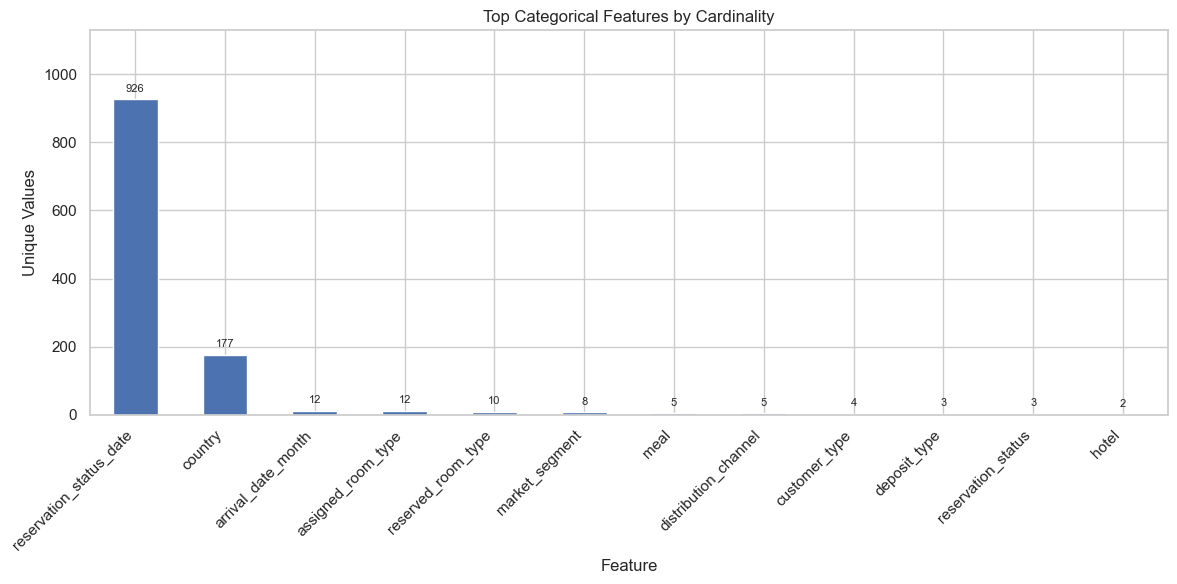

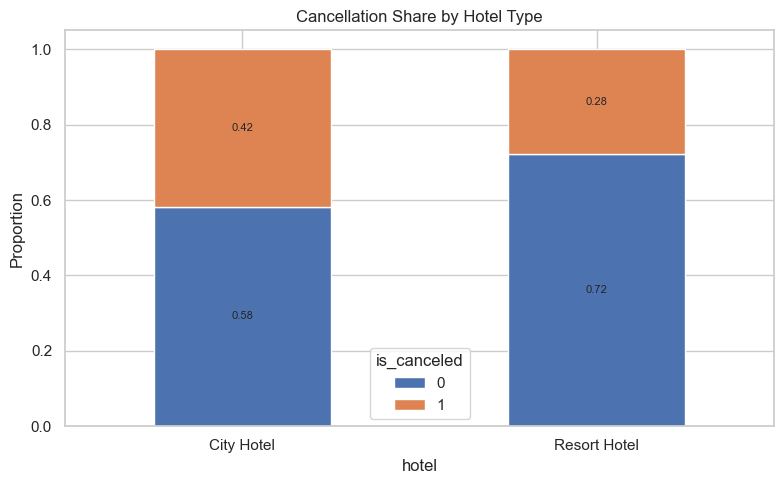

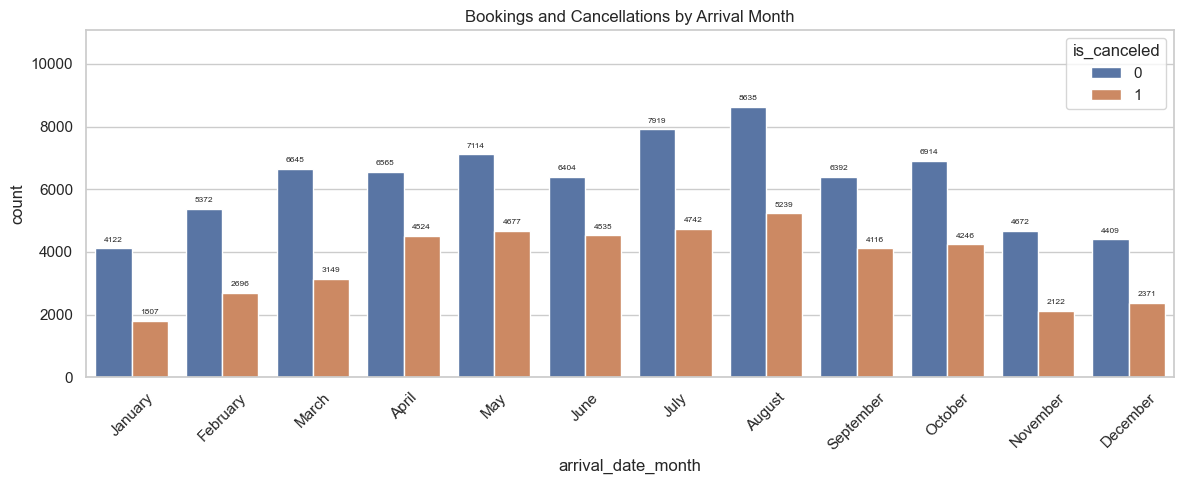

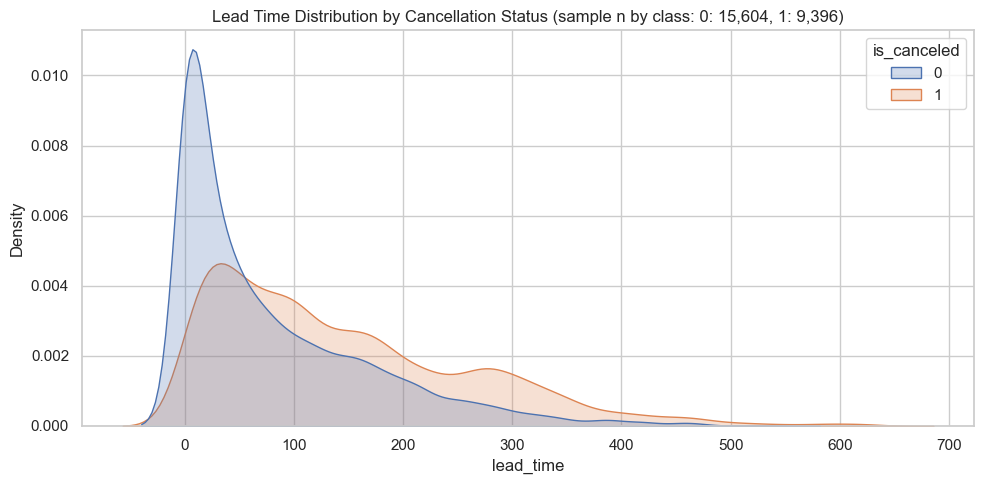

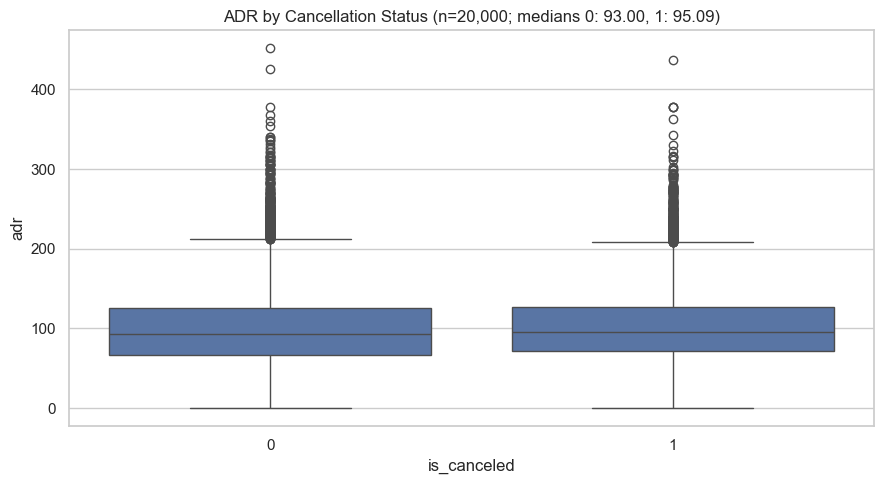

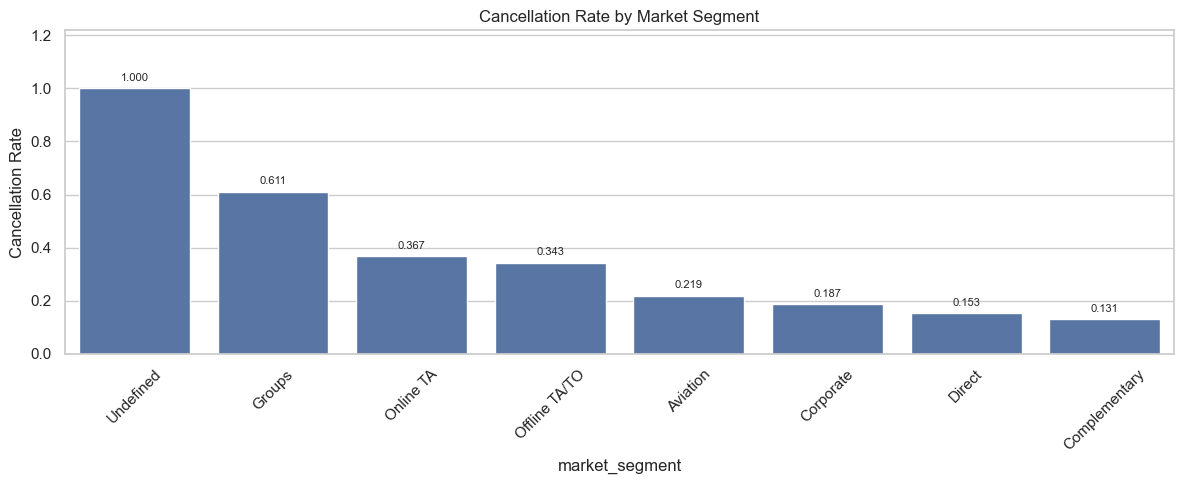

### High-level overview saved to outputs/describing

,rows,columns,duplicate_rows,total_missing_cells,numeric_columns,categorical_columns,memory_usage_mb
0,119390,32,31994,129425,20,12,93.9


### Individual Numeric Boxplots

**Adults**

![Adults](/Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/describing/hotel_booking_dataset_numeric_boxplot_adults.png)

...

![Previous Cancellations](/Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/describing/hotel_booking_dataset_numeric_boxplot_previous_cancellations.png)

**Stays In Week Nights**

![Stays In Week Nights](/Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/describing/hotel_booking_dataset_numeric_boxplot_stays_in_week_nights.png)

**Stays In Weekend Nights**

![Stays In Weekend Nights](/Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/describing/hotel_booking_dataset_numeric_boxplot_stays_in_weekend_nights.png)

In [40]:
bundle = create_dataset_description_bundle(
    df=df_raw,
    output_dir=OUTPUT_DIR,
    prefix="hotel_booking_dataset",
    full=True,
)

display(Markdown("### High-level overview saved to outputs/describing"))
display(pd.DataFrame([bundle["overview"]]))

boxplot_prefix = "hotel_booking_dataset_numeric_boxplot_"
boxplot_files = sorted(OUTPUT_DIR.glob(f"{boxplot_prefix}*.png"))

if boxplot_files:
    display(Markdown("### Individual Numeric Boxplots"))
    for plot_path in boxplot_files:
        feature_name = plot_path.stem.replace(boxplot_prefix, "").replace("_", " ").title()
        display(Markdown(f"**{feature_name}**"))
        display(Markdown(f"![{feature_name}]({plot_path.as_posix()})"))
else:
    display(Markdown(
        "No individual numeric boxplot files found yet. "
        "Re-run Cells 1-7 after restarting the kernel to refresh imports."
    ))